<a href="https://colab.research.google.com/github/mashiruwu/ai_upscaler/blob/main/memora_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PjBL1 - Clusterização de Dados do App Store Connect

## Objetivo

Este trabalho utiliza dados reais do App Store Connect do aplicativo
Memora Flashcards para investigar padrões por meio das técnicas de
clusterização K-Means e DBSCAN.

Serão utilizados dois conjuntos de dados complementares:

- **Dataset 1 - Comportamento diário global:** cada observação representa
  um dia de atividade do aplicativo.

- **Dataset 2 - Comportamento por país:** cada observação representa
  um país ou território da App Store.

## 1. Importação das bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Carregamemnto dos datasets

In [ ]:
df_daily = pd.read_csv("memora_daily_analytics_raw_v2.csv")
df_country = pd.read_csv("memora_country_analytics_raw.csv")

## 3. Análise inicial dos datasets

### 3.1 Dataset diário

In [ ]:
df_daily.head()

,Date,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Total_Downloads,Sessions,Active_Devices,Updates
0,2023-12-01,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-12-02,96.0,24.0,16.33,8.0,0.0,8.0,16.0,1.0,0.0
2,2023-12-03,72.0,10.0,14.63,6.0,0.0,6.0,0.0,0.0,0.0
3,2023-12-04,82.0,10.0,11.11,6.0,0.0,6.0,6.0,3.0,0.0
4,2023-12-05,70.0,8.0,8.16,4.0,0.0,4.0,2.0,2.0,0.0


In [ ]:
df_daily.shape

(1011, 10)

### 3.2 Dataset por país

In [ ]:
df_country.head()

,Country,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Median_Conversion_Rate
0,Afghanistan,8,0,0,0,0.000,0.0
1,Albania,208,3,0,0,0.000,0.0
2,Algeria,32,1,0,5,0.000,0.0
3,Angola,22,1,1,9,0.033,0.0
4,Anguilla,2,0,0,0,0.000,0.0


In [ ]:
df_country.shape

(175, 7)

## 4. Verificação dos tipos de dados

In [ ]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1011 non-null   object 
 1   Impressions           1011 non-null   float64
 2   Product_Page_Views    1011 non-null   float64
 3   Conversion_Rate       1011 non-null   float64
 4   First_Time_Downloads  1011 non-null   float64
 5   Redownloads           1011 non-null   float64
 6   Total_Downloads       1011 non-null   float64
 7   Sessions              1011 non-null   float64
 8   Active_Devices        1011 non-null   float64
 9   Updates               1011 non-null   float64
dtypes: float64(9), object(1)
memory usage: 79.1+ KB


In [ ]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 175 non-null    object 
 1   Impressions             175 non-null    int64  
 2   Product_Page_Views      175 non-null    int64  
 3   Total_Downloads         175 non-null    int64  
 4   Updates                 175 non-null    int64  
 5   Mean_Conversion_Rate    175 non-null    float64
 6   Median_Conversion_Rate  175 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 9.7+ KB


## 5. Pré-processamento inicial

### 5.1 Conversão da coluna de data



In [ ]:
df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1011 non-null   datetime64[ns]
 1   Impressions           1011 non-null   float64       
 2   Product_Page_Views    1011 non-null   float64       
 3   Conversion_Rate       1011 non-null   float64       
 4   First_Time_Downloads  1011 non-null   float64       
 5   Redownloads           1011 non-null   float64       
 6   Total_Downloads       1011 non-null   float64       
 7   Sessions              1011 non-null   float64       
 8   Active_Devices        1011 non-null   float64       
 9   Updates               1011 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 79.1 KB


### 5.2 Verificação de valores ausentes e duplicados

In [ ]:
print("=== DATASET DIÁRIO ===")
print("\nValores ausentes:")
print(df_daily.isnull().sum())

print("\nLinhas duplicadas:")
print(df_daily.duplicated().sum())


print("\n=== DATASET POR PAÍS ===")
print("\nValores ausentes:")
print(df_country.isnull().sum())

print("\nLinhas duplicadas:")
print(df_country.duplicated().sum())

=== DATASET DIÁRIO ===

Valores ausentes:
Date                    0
Impressions             0
Product_Page_Views      0
Conversion_Rate         0
First_Time_Downloads    0
Redownloads             0
Total_Downloads         0
Sessions                0
Active_Devices          0
Updates                 0
dtype: int64

Linhas duplicadas:
0

=== DATASET POR PAÍS ===

Valores ausentes:
Country                   0
Impressions               0
Product_Page_Views        0
Total_Downloads           0
Updates                   0
Mean_Conversion_Rate      0
Median_Conversion_Rate    0
dtype: int64

Linhas duplicadas:
0


## 6. Análise univariada

### 6.1 Estatísticas descritivas



In [ ]:
print("=== DATASET DIÁRIO ===")
display(df_daily.describe().T)

print("\n=== DATASET POR PAÍS ===")
display(df_country.describe().T)

=== DATASET DIÁRIO ===


,count,mean,min,25%,50%,75%,max,std
Date,1011,2025-04-19 00:00:00,2023-12-01 00:00:00,2024-08-09 12:00:00,2025-04-19 00:00:00,2025-12-27 12:00:00,2026-09-06 00:00:00,NaN
Impressions,1011.0,115.439169,0.0,24.0,51.0,104.0,4258.0,314.396252
Product_Page_Views,1011.0,3.209693,0.0,1.0,2.0,4.0,139.0,6.868319
Conversion_Rate,1011.0,2.94816,0.0,0.0,0.0,3.735,71.0,6.039953
First_Time_Downloads,1011.0,0.894164,0.0,0.0,0.0,1.0,97.0,3.896644
Redownloads,1011.0,0.105836,0.0,0.0,0.0,0.0,3.0,0.379781
Total_Downloads,1011.0,1.0,0.0,0.0,0.0,1.0,100.0,4.01211
Sessions,1011.0,1.835806,0.0,0.0,0.0,1.0,167.0,7.17233
Active_Devices,1011.0,0.603363,0.0,0.0,0.0,1.0,17.0,1.067962
Updates,1011.0,4.457962,0.0,0.0,2.0,3.0,120.0,11.740468



=== DATASET POR PAÍS ===


,count,mean,std,min,25%,50%,75%,max
Impressions,175.0,666.908571,2000.820875,0.0,5.0,49.0,464.50000,21325.0000
Product_Page_Views,175.0,18.542857,70.151782,0.0,0.0,2.0,10.50000,769.0000
Total_Downloads,175.0,5.777143,25.073720,0.0,0.0,0.0,4.00000,287.0000
Updates,175.0,25.754286,88.374609,0.0,0.0,0.0,13.50000,896.0000
Mean_Conversion_Rate,175.0,0.226307,0.470777,0.0,0.0,0.0,0.25965,3.6241
Median_Conversion_Rate,175.0,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0000


In [ ]:
print("=== MODA - DATASET DIÁRIO ===")
display(df_daily.select_dtypes(include="number").mode().iloc[0])

print("\n=== MODA - DATASET POR PAÍS ===")
display(df_country.select_dtypes(include="number").mode().iloc[0])

=== MODA - DATASET DIÁRIO ===


,0
Impressions,0.0
Product_Page_Views,1.0
Conversion_Rate,0.0
First_Time_Downloads,0.0
Redownloads,0.0
Total_Downloads,0.0
Sessions,0.0
Active_Devices,0.0
Updates,0.0



=== MODA - DATASET POR PAÍS ===


,0
Impressions,0.0
Product_Page_Views,0.0
Total_Downloads,0.0
Updates,0.0
Mean_Conversion_Rate,0.0
Median_Conversion_Rate,0.0


## 7. Visualização das distribuições

Os histogramas abaixo permitem observar a distribuição das variáveis,
identificando concentração de valores, assimetria e possíveis valores
extremos antes da etapa de clusterização.

## 7.1 Dataset diário

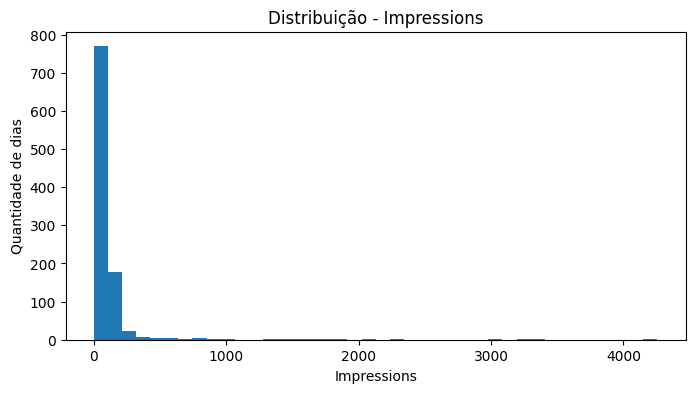

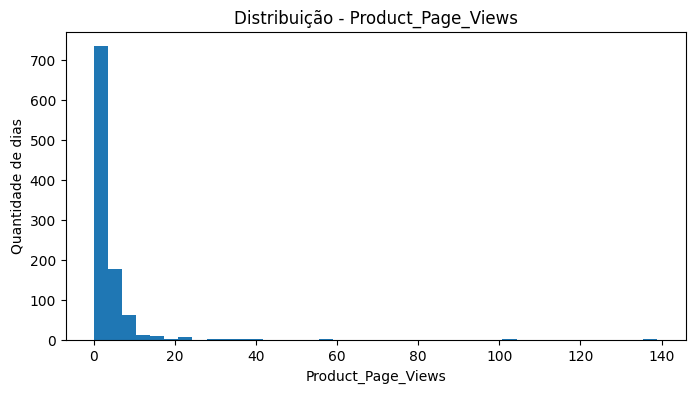

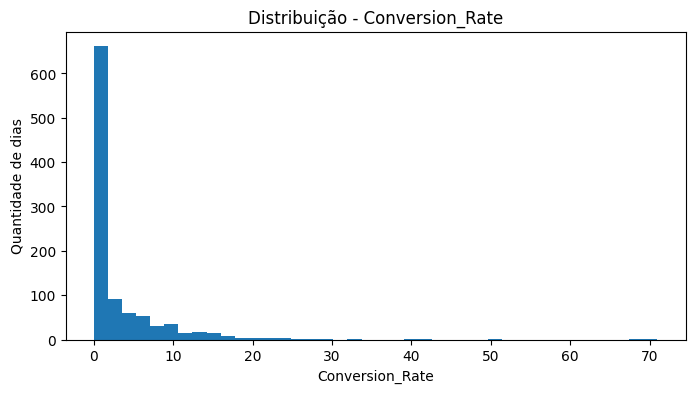

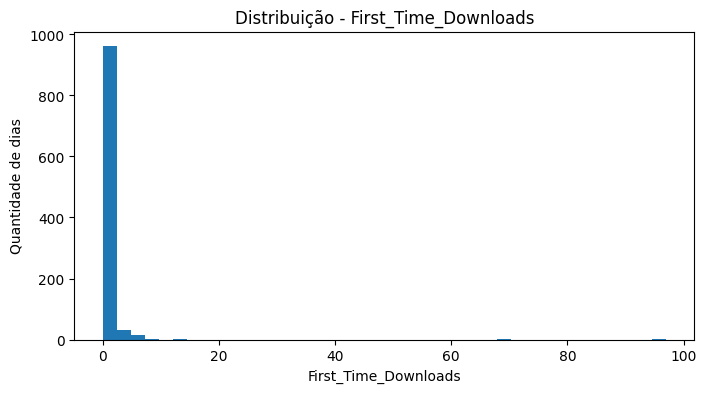

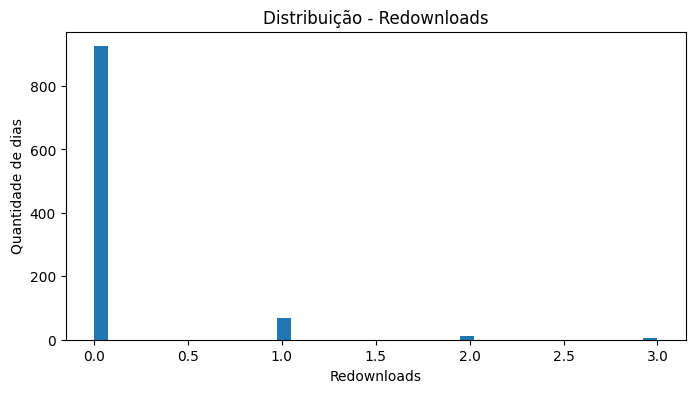

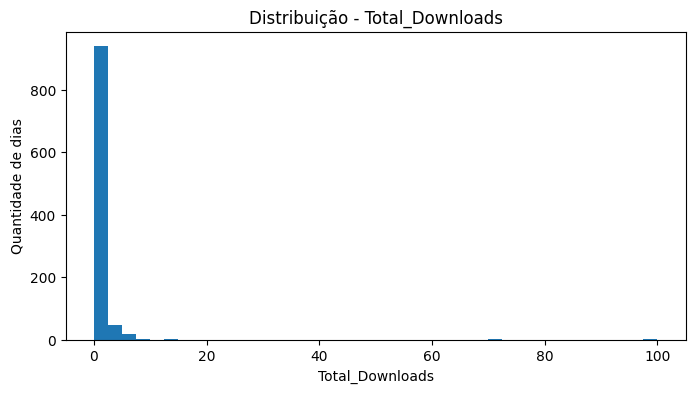

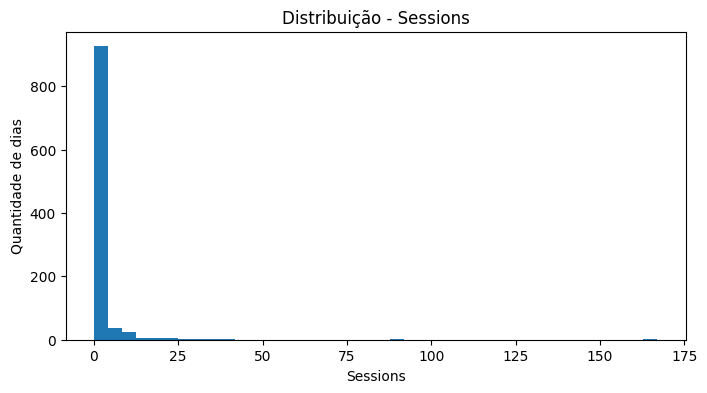

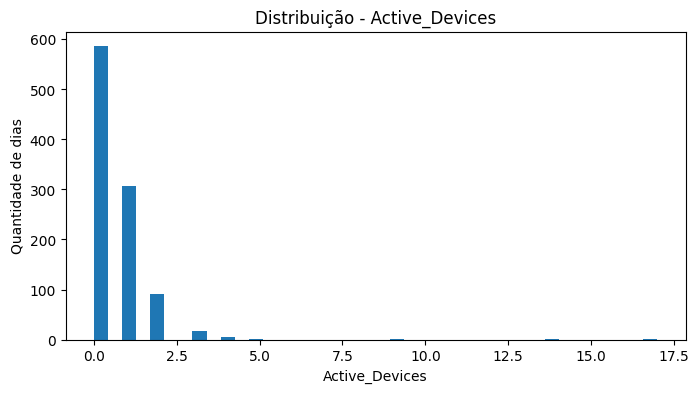

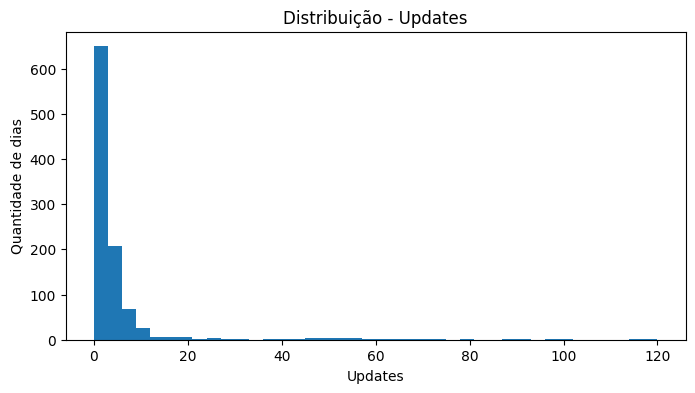

In [ ]:
daily_numeric = df_daily.select_dtypes(include="number").columns

for column in daily_numeric:
    plt.figure(figsize=(8, 4))
    plt.hist(df_daily[column], bins=40)
    plt.title(f"Distribuição - {column}")
    plt.xlabel(column)
    plt.ylabel("Quantidade de dias")
    plt.show()

## 7.2 Dataset por país

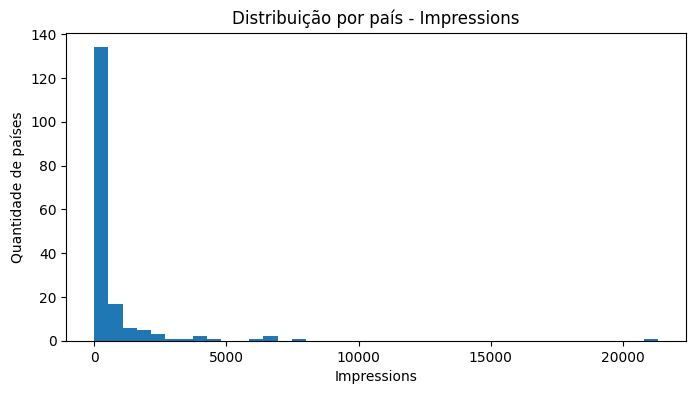

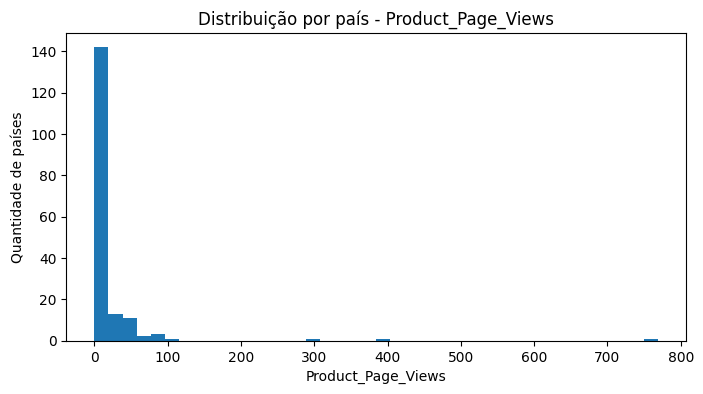

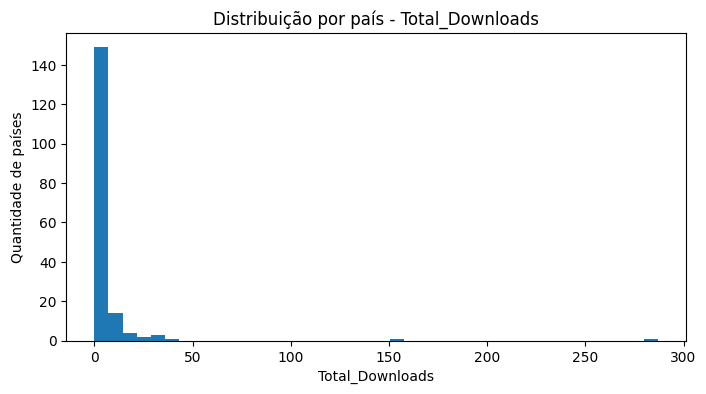

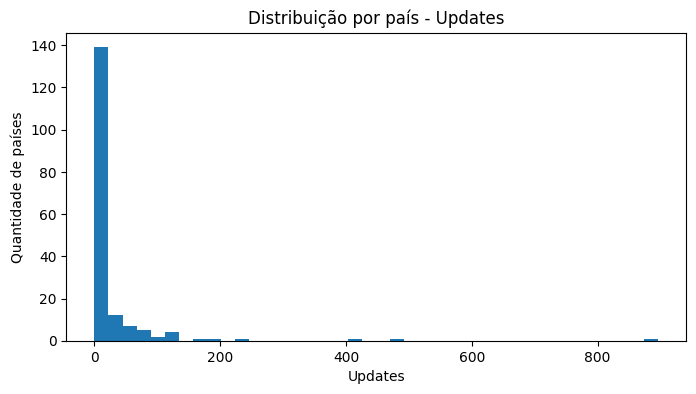

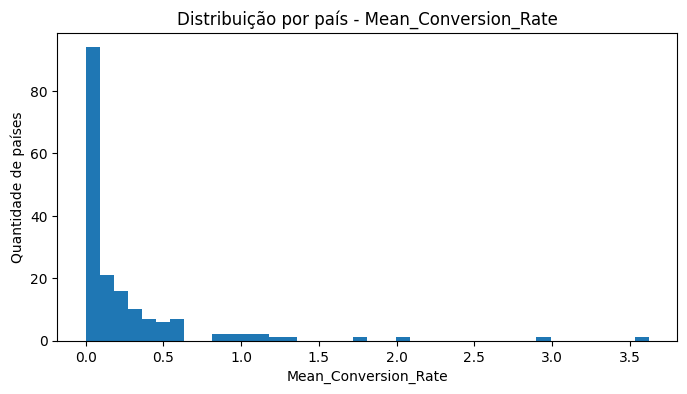

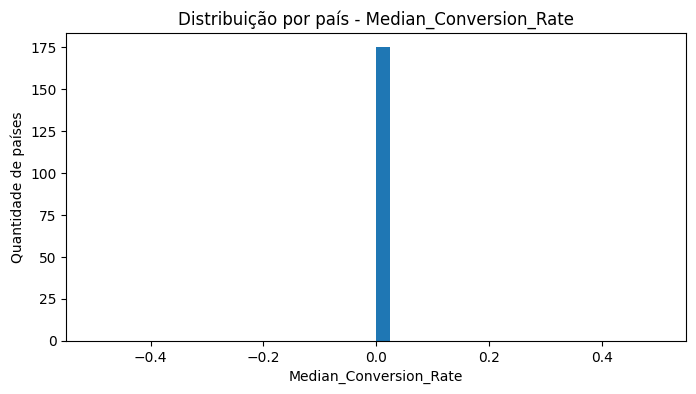

In [ ]:
country_numeric = df_country.select_dtypes(include="number").columns

for column in country_numeric:
    plt.figure(figsize=(8, 4))
    plt.hist(df_country[column], bins=40)
    plt.title(f"Distribuição por país - {column}")
    plt.xlabel(column)
    plt.ylabel("Quantidade de países")
    plt.show()

## 8. Análise multivariada

Nesta etapa são analisadas as relações entre as variáveis numéricas dos
dois datasets por meio de matrizes de correlação.

## 8.1 Correlação - Dataset diário

In [ ]:
daily_corr = df_daily.select_dtypes(include="number").corr()

daily_corr.round(2)

,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Total_Downloads,Sessions,Active_Devices,Updates
Impressions,1.00,0.42,-0.10,0.10,0.03,0.10,0.00,0.13,0.03
Product_Page_Views,0.42,1.00,0.46,0.84,0.24,0.84,0.15,0.62,0.08
Conversion_Rate,-0.10,0.46,1.00,0.61,0.34,0.62,0.21,0.51,0.05
First_Time_Downloads,0.10,0.84,0.61,1.00,0.26,1.00,0.19,0.70,0.07
Redownloads,0.03,0.24,0.34,0.26,1.00,0.35,0.06,0.24,0.30
Total_Downloads,0.10,0.84,0.62,1.00,0.35,1.00,0.19,0.70,0.10
Sessions,0.00,0.15,0.21,0.19,0.06,0.19,1.00,0.37,0.03
Active_Devices,0.13,0.62,0.51,0.70,0.24,0.70,0.37,1.00,0.16
Updates,0.03,0.08,0.05,0.07,0.30,0.10,0.03,0.16,1.00


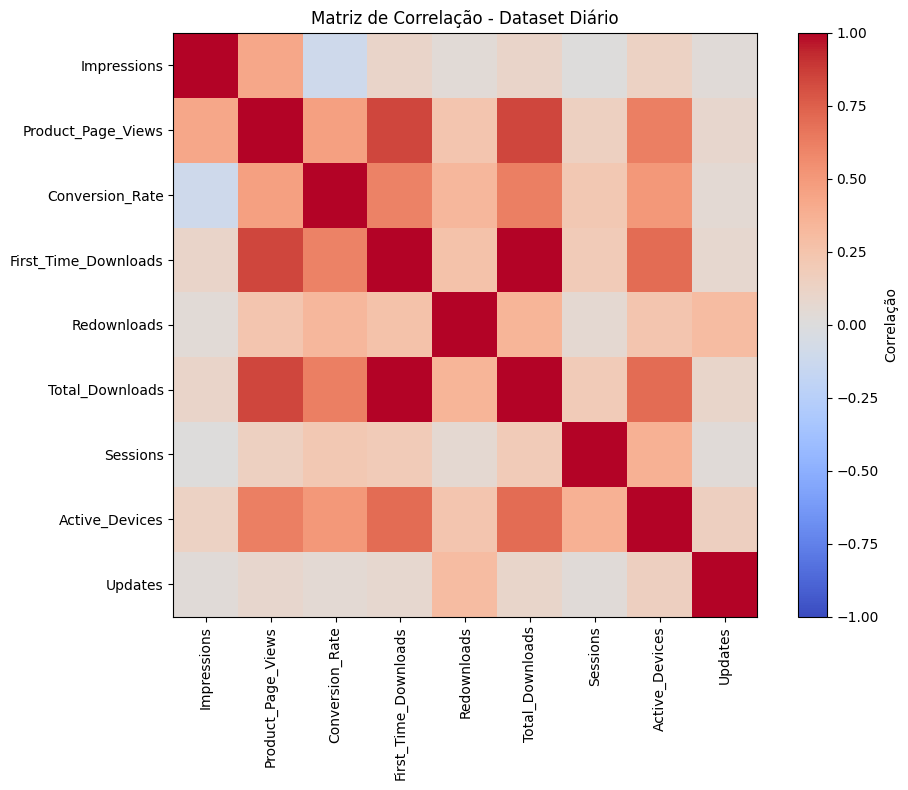

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(daily_corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(daily_corr.columns)),
    daily_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(daily_corr.columns)),
    daily_corr.columns
)

plt.title("Matriz de Correlação - Dataset Diário")

plt.tight_layout()
plt.show()

## 8.2 Correlação — Dataset por país

In [ ]:
country_corr = df_country.select_dtypes(include="number").corr()

country_corr.round(2)

,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Median_Conversion_Rate
Impressions,1.00,0.64,0.45,0.59,0.41,NaN
Product_Page_Views,0.64,1.00,0.97,0.93,0.74,NaN
Total_Downloads,0.45,0.97,1.00,0.92,0.78,NaN
Updates,0.59,0.93,0.92,1.00,0.79,NaN
Mean_Conversion_Rate,0.41,0.74,0.78,0.79,1.00,NaN
Median_Conversion_Rate,NaN,NaN,NaN,NaN,NaN,NaN


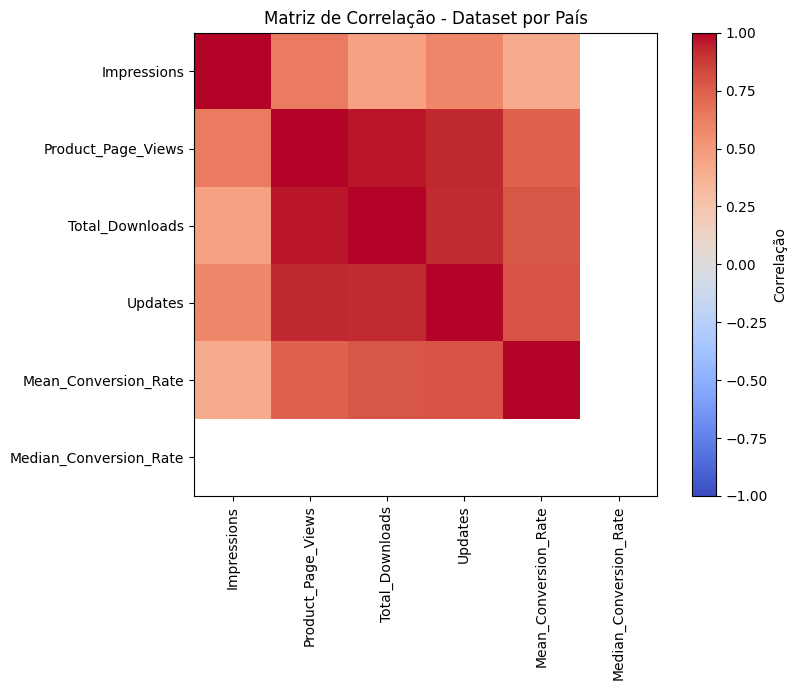

In [ ]:
plt.figure(figsize=(9, 7))

plt.imshow(country_corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(country_corr.columns)),
    country_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(country_corr.columns)),
    country_corr.columns
)

plt.title("Matriz de Correlação - Dataset por País")

plt.tight_layout()
plt.show()

### 8.3 Correlação de Spearman

In [ ]:
daily_spearman = (
    df_daily
    .select_dtypes(include="number")
    .corr(method="spearman")
)

daily_spearman.round(2)

,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Total_Downloads,Sessions,Active_Devices,Updates
Impressions,1.00,0.41,-0.13,0.10,0.09,0.12,-0.06,-0.04,0.12
Product_Page_Views,0.41,1.00,0.31,0.41,0.14,0.42,0.15,0.15,0.10
Conversion_Rate,-0.13,0.31,1.00,0.86,0.30,0.90,0.36,0.34,0.05
First_Time_Downloads,0.10,0.41,0.86,1.00,0.11,0.95,0.35,0.34,0.05
Redownloads,0.09,0.14,0.30,0.11,1.00,0.38,0.11,0.12,0.18
Total_Downloads,0.12,0.42,0.90,0.95,0.38,1.00,0.36,0.35,0.10
Sessions,-0.06,0.15,0.36,0.35,0.11,0.36,1.00,0.96,0.04
Active_Devices,-0.04,0.15,0.34,0.34,0.12,0.35,0.96,1.00,0.07
Updates,0.12,0.10,0.05,0.05,0.18,0.10,0.04,0.07,1.00


In [ ]:
country_spearman = (
    df_country
    .select_dtypes(include="number")
    .corr(method="spearman")
)

country_spearman.round(2)

,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Median_Conversion_Rate
Impressions,1.00,0.91,0.80,0.69,0.76,NaN
Product_Page_Views,0.91,1.00,0.87,0.76,0.84,NaN
Total_Downloads,0.80,0.87,1.00,0.86,0.98,NaN
Updates,0.69,0.76,0.86,1.00,0.85,NaN
Mean_Conversion_Rate,0.76,0.84,0.98,0.85,1.00,NaN
Median_Conversion_Rate,NaN,NaN,NaN,NaN,NaN,NaN


### 8.4 Interpretação das correlações

#### Dataset diário

A análise de correlação mostrou que algumas variáveis apresentam relações
fortes entre si.

`Product_Page_Views` apresenta forte relação com os downloads, indicando que
dias com maior número de visitas à página do aplicativo tendem também a
apresentar mais downloads.

`First_Time_Downloads` e `Total_Downloads` apresentam correlação muito alta,
o que é esperado, pois os primeiros downloads representam a maior parte dos
downloads totais observados no período.

Também foi observada uma diferença relevante entre Pearson e Spearman para
algumas variáveis. Por exemplo, `Sessions` e `Active_Devices` apresentam uma
correlação de Spearman muito alta, indicando que as duas métricas tendem a
aumentar e diminuir juntas, mesmo que a relação não seja perfeitamente linear.

As impressões, por outro lado, apresentam correlação relativamente baixa com
downloads no dataset diário, sugerindo que um aumento de exposição na App
Store não necessariamente resulta diretamente em mais downloads.

#### Dataset por país

No dataset por país, foram encontradas relações fortes entre exposição,
visualizações da página e downloads.

`Impressions` e `Product_Page_Views` apresentam forte correlação de Spearman,
indicando que países com maior exposição do aplicativo tendem também a gerar
mais visitas à página.

`Product_Page_Views` e `Total_Downloads` também apresentam forte correlação,
mostrando uma relação clara entre interesse pela página e aquisição do app.

A diferença entre os resultados de Pearson e Spearman indica que existem
países com valores extremos que afetam a relação linear entre as variáveis.

A variável `Median_Conversion_Rate` apresentou valores NaN na matriz de
correlação porque possui o mesmo valor para todos os países, não apresentando
variação suficiente para o cálculo da correlação.

## 9. Preparação dos dados para clusterização

Antes de aplicar os algoritmos de clusterização, é necessário selecionar
as variáveis que serão utilizadas para representar cada observação.

As colunas utilizadas apenas como identificação, como data e país, não
devem participar diretamente do cálculo das distâncias entre os pontos.

### 9.1 Separação das features

In [ ]:
daily_features = df_daily.drop(columns=["Date"]).copy()

country_features = df_country.drop(columns=["Country"]).copy()

In [ ]:
print("Features do dataset diário:")
print(daily_features.columns.tolist())

print("\nFeatures do dataset por país:")
print(country_features.columns.tolist())

Features do dataset diário:
['Impressions', 'Product_Page_Views', 'Conversion_Rate', 'First_Time_Downloads', 'Redownloads', 'Total_Downloads', 'Sessions', 'Active_Devices', 'Updates']

Features do dataset por país:
['Impressions', 'Product_Page_Views', 'Total_Downloads', 'Updates', 'Mean_Conversion_Rate', 'Median_Conversion_Rate']


### 9.2 Identificação de variáveis sem informação ou redundantes

In [ ]:
print("Valores únicos por feature - Dataset diário:")
display(daily_features.nunique())

print("Valores únicos por feature - Dataset por país:")
display(country_features.nunique())

Valores únicos por feature - Dataset diário:


,0
Impressions,240
Product_Page_Views,30
Conversion_Rate,198
First_Time_Downloads,12
Redownloads,4
Total_Downloads,12
Sessions,30
Active_Devices,9
Updates,54


Valores únicos por feature - Dataset por país:


,0
Impressions,115
Product_Page_Views,46
Total_Downloads,23
Updates,46
Mean_Conversion_Rate,58
Median_Conversion_Rate,1


In [ ]:
daily_features = daily_features.drop(columns=["Total_Downloads"])

country_features = country_features.drop(columns=["Median_Conversion_Rate"])

In [ ]:
print("Dataset diário:")
print(daily_features.columns.tolist())

print("\nDataset por país:")
print(country_features.columns.tolist())

Dataset diário:
['Impressions', 'Product_Page_Views', 'Conversion_Rate', 'First_Time_Downloads', 'Redownloads', 'Sessions', 'Active_Devices', 'Updates']

Dataset por país:
['Impressions', 'Product_Page_Views', 'Total_Downloads', 'Updates', 'Mean_Conversion_Rate']


### 9.3 Engenharia de features

Além das métricas absolutas, foram criadas variáveis derivadas para
representar relações de eficiência e comportamento dentro do funil
de aquisição e uso do aplicativo.

In [ ]:
daily_features["Page_View_Rate"] = (
    daily_features["Product_Page_Views"]
    / daily_features["Impressions"]
)

daily_features["Sessions_Per_Active_Device"] = (
    daily_features["Sessions"]
    / daily_features["Active_Devices"]
)

In [ ]:
country_features["Page_View_Rate"] = (
    country_features["Product_Page_Views"]
    / country_features["Impressions"]
)

country_features["Downloads_Per_Page_View"] = (
    country_features["Total_Downloads"]
    / country_features["Product_Page_Views"]
)

### 9.4 Verificação das novas features

In [ ]:
print("Dataset diário:")
display(daily_features.head())

print("\nDataset por país:")
display(country_features.head())

Dataset diário:


,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Sessions,Active_Devices,Updates,Page_View_Rate,Sessions_Per_Active_Device
0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,96.0,24.0,16.33,8.0,0.0,16.0,1.0,0.0,0.250000,16.0
2,72.0,10.0,14.63,6.0,0.0,0.0,0.0,0.0,0.138889,NaN
3,82.0,10.0,11.11,6.0,0.0,6.0,3.0,0.0,0.121951,2.0
4,70.0,8.0,8.16,4.0,0.0,2.0,2.0,0.0,0.114286,1.0



Dataset por país:


,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Page_View_Rate,Downloads_Per_Page_View
0,8,0,0,0,0.000,0.000000,NaN
1,208,3,0,0,0.000,0.014423,0.0
2,32,1,0,5,0.000,0.031250,0.0
3,22,1,1,9,0.033,0.045455,1.0
4,2,0,0,0,0.000,0.000000,NaN


In [ ]:
print("Valores ausentes - Dataset diário:")
print(daily_features.isnull().sum())

print("\nValores ausentes - Dataset por país:")
print(country_features.isnull().sum())

Valores ausentes - Dataset diário:
Impressions                     0
Product_Page_Views              0
Conversion_Rate                 0
First_Time_Downloads            0
Redownloads                     0
Sessions                        0
Active_Devices                  0
Updates                         0
Page_View_Rate                 31
Sessions_Per_Active_Device    583
dtype: int64

Valores ausentes - Dataset por país:
Impressions                 0
Product_Page_Views          0
Total_Downloads             0
Updates                     0
Mean_Conversion_Rate        0
Page_View_Rate             10
Downloads_Per_Page_View    65
dtype: int64


In [ ]:
print("Infinitos - Dataset diário:")
print(np.isinf(daily_features.select_dtypes(include="number")).sum())

print("\nInfinitos - Dataset por país:")
print(np.isinf(country_features.select_dtypes(include="number")).sum())

Infinitos - Dataset diário:
Impressions                   0
Product_Page_Views            0
Conversion_Rate               0
First_Time_Downloads          0
Redownloads                   0
Sessions                      0
Active_Devices                0
Updates                       0
Page_View_Rate                0
Sessions_Per_Active_Device    3
dtype: int64

Infinitos - Dataset por país:
Impressions                0
Product_Page_Views         0
Total_Downloads            0
Updates                    0
Mean_Conversion_Rate       0
Page_View_Rate             0
Downloads_Per_Page_View    3
dtype: int64


### 9.5 Tratamento de valores indefinidos nas features derivadas

As features derivadas envolvem divisões entre métricas. Quando o denominador
é zero, podem surgir valores `NaN` ou infinitos.

Esses casos são tratados de forma controlada, evitando substituir
indiscriminadamente valores indefinidos por zero.

In [ ]:
daily_features = daily_features.replace([np.inf, -np.inf], np.nan)
country_features = country_features.replace([np.inf, -np.inf], np.nan)

In [ ]:
daily_features.loc[
    (daily_features["Impressions"] == 0) &
    (daily_features["Product_Page_Views"] == 0),
    "Page_View_Rate"
] = 0

daily_features.loc[
    (daily_features["Active_Devices"] == 0) &
    (daily_features["Sessions"] == 0),
    "Sessions_Per_Active_Device"
] = 0

In [ ]:
country_features.loc[
    (country_features["Impressions"] == 0) &
    (country_features["Product_Page_Views"] == 0),
    "Page_View_Rate"
] = 0

country_features.loc[
    (country_features["Product_Page_Views"] == 0) &
    (country_features["Total_Downloads"] == 0),
    "Downloads_Per_Page_View"
] = 0

In [ ]:
print("Valores ausentes - Dataset diário:")
print(daily_features.isnull().sum())

print("\nValores ausentes - Dataset por país:")
print(country_features.isnull().sum())

Valores ausentes - Dataset diário:
Impressions                   0
Product_Page_Views            0
Conversion_Rate               0
First_Time_Downloads          0
Redownloads                   0
Sessions                      0
Active_Devices                0
Updates                       0
Page_View_Rate                0
Sessions_Per_Active_Device    3
dtype: int64

Valores ausentes - Dataset por país:
Impressions                0
Product_Page_Views         0
Total_Downloads            0
Updates                    0
Mean_Conversion_Rate       0
Page_View_Rate             0
Downloads_Per_Page_View    3
dtype: int64


### 9.6 Transformação das variáveis de volume

As métricas de volume apresentam distribuições fortemente assimétricas,
com grande concentração de valores baixos e alguns valores extremos.

Para reduzir a influência desses picos sem remover observações reais,
foi aplicada a transformação `log1p` às variáveis de contagem.

A transformação `log1p(x)` corresponde a `log(1 + x)` e permite tratar
naturalmente valores iguais a zero.

In [ ]:
daily_prepared = daily_features.copy()
country_prepared = country_features.copy()

In [ ]:
daily_count_columns = [
    "Impressions",
    "Product_Page_Views",
    "First_Time_Downloads",
    "Redownloads",
    "Sessions",
    "Active_Devices",
    "Updates"
]

In [ ]:
country_count_columns = [
    "Impressions",
    "Product_Page_Views",
    "Total_Downloads",
    "Updates"
]

In [ ]:
for column in daily_count_columns:
    daily_prepared[column] = np.log1p(daily_prepared[column])

for column in country_count_columns:
    country_prepared[column] = np.log1p(country_prepared[column])

In [ ]:
print("Dataset diário antes:")
display(daily_features.head())

print("\nDataset diário preparado:")
display(daily_prepared.head())

print("\nDataset por país antes:")
display(country_features.head())

print("\nDataset por país preparado:")
display(country_prepared.head())

Dataset diário antes:


,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Sessions,Active_Devices,Updates,Page_View_Rate,Sessions_Per_Active_Device
0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,96.0,24.0,16.33,8.0,0.0,16.0,1.0,0.0,0.250000,16.0
2,72.0,10.0,14.63,6.0,0.0,0.0,0.0,0.0,0.138889,0.0
3,82.0,10.0,11.11,6.0,0.0,6.0,3.0,0.0,0.121951,2.0
4,70.0,8.0,8.16,4.0,0.0,2.0,2.0,0.0,0.114286,1.0



Dataset diário preparado:


,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Sessions,Active_Devices,Updates,Page_View_Rate,Sessions_Per_Active_Device
0,0.000000,0.000000,0.00,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
1,4.574711,3.218876,16.33,2.197225,0.0,2.833213,0.693147,0.0,0.250000,16.0
2,4.290459,2.397895,14.63,1.945910,0.0,0.000000,0.000000,0.0,0.138889,0.0
3,4.418841,2.397895,11.11,1.945910,0.0,1.945910,1.386294,0.0,0.121951,2.0
4,4.262680,2.197225,8.16,1.609438,0.0,1.098612,1.098612,0.0,0.114286,1.0



Dataset por país antes:


,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Page_View_Rate,Downloads_Per_Page_View
0,8,0,0,0,0.000,0.000000,0.0
1,208,3,0,0,0.000,0.014423,0.0
2,32,1,0,5,0.000,0.031250,0.0
3,22,1,1,9,0.033,0.045455,1.0
4,2,0,0,0,0.000,0.000000,0.0



Dataset por país preparado:


,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Page_View_Rate,Downloads_Per_Page_View
0,2.197225,0.000000,0.000000,0.000000,0.000,0.000000,0.0
1,5.342334,1.386294,0.000000,0.000000,0.000,0.014423,0.0
2,3.496508,0.693147,0.000000,1.791759,0.000,0.031250,0.0
3,3.135494,0.693147,0.693147,2.302585,0.033,0.045455,1.0
4,1.098612,0.000000,0.000000,0.000000,0.000,0.000000,0.0


### 9.7 Padronização das features

Como K-Means e DBSCAN utilizam medidas de distância, é necessário colocar
as features em escalas comparáveis.

Foi utilizado o `StandardScaler`, que transforma cada variável para uma
escala com média aproximadamente 0 e desvio padrão aproximadamente 1.

In [ ]:
daily_scaler = StandardScaler()
country_scaler = StandardScaler()

In [ ]:
daily_scaled = daily_scaler.fit_transform(daily_prepared)

country_scaled = country_scaler.fit_transform(country_prepared)

In [ ]:
daily_scaled = pd.DataFrame(
    daily_scaled,
    columns=daily_prepared.columns,
    index=daily_prepared.index
)

country_scaled = pd.DataFrame(
    country_scaled,
    columns=country_prepared.columns,
    index=country_prepared.index
)

In [ ]:
display(daily_scaled.head())
display(country_scaled.head())

,Impressions,Product_Page_Views,Conversion_Rate,First_Time_Downloads,Redownloads,Sessions,Active_Devices,Updates,Page_View_Rate,Sessions_Per_Active_Device
0,-3.260895,-1.377249,-0.488351,-0.794904,-0.295061,-0.676854,-0.781505,-1.073724,-0.731885,-0.306377
1,0.532398,2.772215,2.216650,3.400794,-0.295061,2.956568,0.757424,-1.073724,2.689613,3.549443
2,0.296700,1.713886,1.935052,2.920898,-0.295061,-0.676854,-0.781505,-1.073724,1.168947,-0.306377
3,0.403153,1.713886,1.351977,2.920898,-0.295061,1.818656,2.296353,-1.073724,0.937138,0.175601
4,0.273666,1.455201,0.863321,2.278389,-0.295061,0.732049,1.657640,-1.073724,0.832228,-0.065388


,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate,Page_View_Rate,Downloads_Per_Page_View
0,-0.742490,-0.957803,-0.785396,-0.699836,-0.482088,-0.606952,-0.676432
1,0.515499,-0.050985,-0.785396,-0.699836,-0.482088,-0.354780,-0.676432
2,-0.222800,-0.504394,-0.785396,0.297858,-0.482088,-0.060579,-0.676432
3,-0.367199,-0.504394,-0.165271,0.582298,-0.411790,0.187772,2.269085
4,-1.181916,-0.957803,-0.785396,-0.699836,-0.482088,-0.606952,-0.676432


In [ ]:
print("Médias - Dataset diário:")
print(daily_scaled.mean().round(2))

print("\nDesvios padrão - Dataset diário:")
print(daily_scaled.std().round(2))

Médias - Dataset diário:
Impressions                   0.0
Product_Page_Views           -0.0
Conversion_Rate              -0.0
First_Time_Downloads          0.0
Redownloads                  -0.0
Sessions                     -0.0
Active_Devices                0.0
Updates                      -0.0
Page_View_Rate               -0.0
Sessions_Per_Active_Device   -0.0
dtype: float64

Desvios padrão - Dataset diário:
Impressions                   1.0
Product_Page_Views            1.0
Conversion_Rate               1.0
First_Time_Downloads          1.0
Redownloads                   1.0
Sessions                      1.0
Active_Devices                1.0
Updates                       1.0
Page_View_Rate                1.0
Sessions_Per_Active_Device    1.0
dtype: float64


In [ ]:
print("Médias - Dataset por país:")
print(country_scaled.mean().round(2))

print("\nDesvios padrão - Dataset por país:")
print(country_scaled.std().round(2))

Médias - Dataset por país:
Impressions               -0.0
Product_Page_Views         0.0
Total_Downloads           -0.0
Updates                    0.0
Mean_Conversion_Rate      -0.0
Page_View_Rate            -0.0
Downloads_Per_Page_View    0.0
dtype: float64

Desvios padrão - Dataset por país:
Impressions                1.0
Product_Page_Views         1.0
Total_Downloads            1.0
Updates                    1.0
Mean_Conversion_Rate       1.0
Page_View_Rate             1.0
Downloads_Per_Page_View    1.0
dtype: float64


## 10. K-Means

O K-Means agrupa as observações em `k` clusters com base na proximidade
entre os pontos.

Como o número de clusters precisa ser definido previamente, serão testados
diferentes valores de `k` utilizando métricas de avaliação.

### 10.1 Escolha do número de clusters — Dataset diário

In [ ]:
daily_prepared["Sessions_Per_Active_Device"] = (
    daily_prepared["Sessions_Per_Active_Device"]
    .fillna(daily_prepared["Sessions_Per_Active_Device"].median())
)

In [ ]:
daily_scaled.isnull().sum().sum()

np.int64(3)

In [ ]:
daily_scaled = pd.DataFrame(
    daily_scaler.fit_transform(daily_prepared),
    columns=daily_prepared.columns,
    index=daily_prepared.index
)

In [ ]:
daily_inertias = []
daily_silhouettes = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(daily_scaled)

    daily_inertias.append(kmeans.inertia_)
    daily_silhouettes.append(
        silhouette_score(daily_scaled, labels)
    )

### 10.2 Método do Cotovelo — Dataset diário

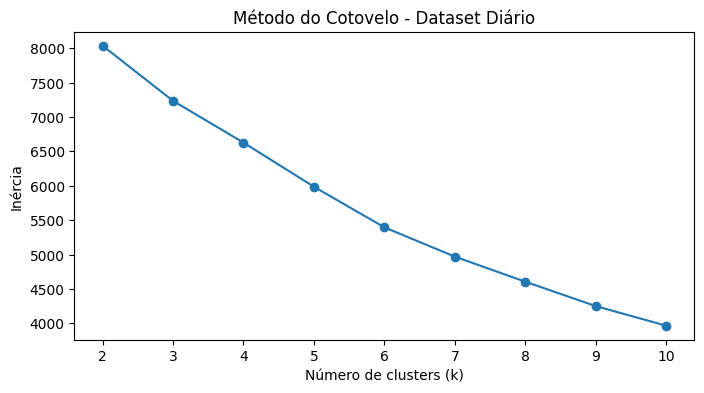

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(k_values, daily_inertias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo - Dataset Diário")

plt.show()

### 10.3 Silhouette Score — Dataset diário

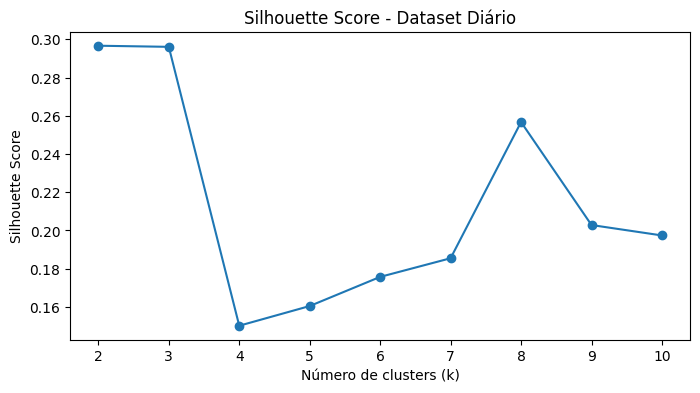

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(k_values, daily_silhouettes, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Dataset Diário")

plt.show()

In [ ]:
for k, score in zip(k_values, daily_silhouettes):
    print(f"k={k}: {score:.4f}")

k=2: 0.2966
k=3: 0.2961
k=4: 0.1501
k=5: 0.1604
k=6: 0.1757
k=7: 0.1854
k=8: 0.2567
k=9: 0.2028
k=10: 0.1974


### 10.4 Escolha de k — Dataset diário

O método do cotovelo não apresentou uma quebra extremamente evidente, indicando
que a estrutura dos dados não possui uma separação muito clara em vários grupos.

O Silhouette Score apresentou seu maior valor para `k = 2` (0,2966), seguido
muito de perto por `k = 3` (0,2961).

Dessa forma, `k = 2` foi selecionado como configuração principal do K-Means
para o dataset diário, por apresentar o melhor Silhouette Score.

Os valores relativamente baixos de Silhouette também indicam que os clusters
não são fortemente separados, o que é esperado em dados reais de comportamento
de usuários e será posteriormente comparado com os resultados do DBSCAN.

### 10.5 Escolha do número de clusters — Dataset por país

In [ ]:
country_prepared = country_prepared.drop(
    columns=["Downloads_Per_Page_View"]
)

In [ ]:
country_scaled = pd.DataFrame(
    country_scaler.fit_transform(country_prepared),
    columns=country_prepared.columns,
    index=country_prepared.index
)

In [ ]:
country_inertias = []
country_silhouettes = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(country_scaled)

    country_inertias.append(kmeans.inertia_)
    country_silhouettes.append(
        silhouette_score(country_scaled, labels)
    )

### 10.6 Método do Cotovelo — Dataset por país

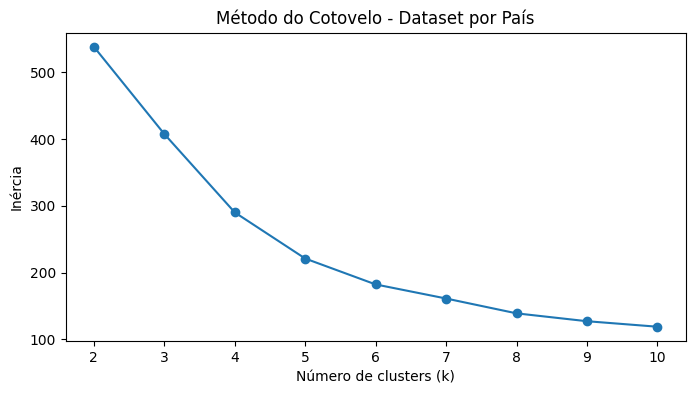

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(k_values, country_inertias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo - Dataset por País")

plt.show()

### 10.7 Silhouette Score — Dataset por país

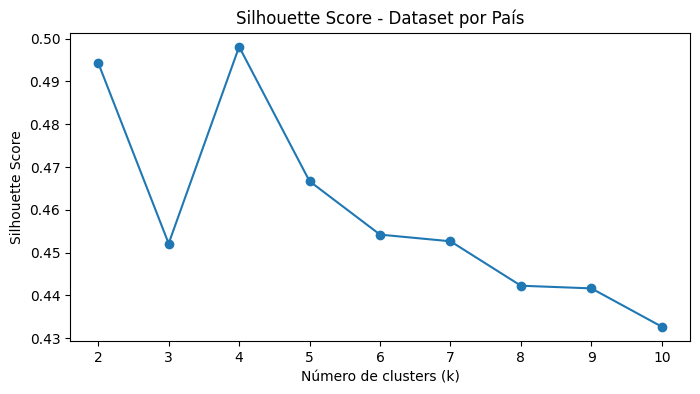

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(k_values, country_silhouettes, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Dataset por País")

plt.show()

In [ ]:
for k, score in zip(k_values, country_silhouettes):
    print(f"k={k}: {score:.4f}")

k=2: 0.4943
k=3: 0.4521
k=4: 0.4981
k=5: 0.4667
k=6: 0.4542
k=7: 0.4527
k=8: 0.4423
k=9: 0.4417
k=10: 0.4327


### 10.8 Escolha de k — Dataset por país

O método do cotovelo apresentou redução acentuada da inércia até
aproximadamente `k = 4`, após o qual os ganhos passaram a ser menores.

O maior Silhouette Score foi obtido com `k = 4` (0,4981), ligeiramente
superior ao resultado de `k = 2` (0,4943).

Dessa forma, foi escolhido `k = 4` para o dataset por país, por apresentar
a melhor separação entre os grupos e também uma solução mais informativa
para a identificação de diferentes perfis de mercado.

In [ ]:
kmeans_country = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

country_labels = kmeans_country.fit_predict(country_scaled)

df_country["KMeans_Cluster"] = country_labels

In [ ]:
for cluster in sorted(df_country["KMeans_Cluster"].unique()):
    print(f"\nCluster {cluster}")
    display(
        df_country[
            df_country["KMeans_Cluster"] == cluster
        ][
            [
                "Country",
                "Impressions",
                "Product_Page_Views",
                "Total_Downloads",
                "Updates",
                "Mean_Conversion_Rate"
            ]
        ].sort_values(
            "Total_Downloads",
            ascending=False
        )
    )


Cluster 0


,Country,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate
140,Slovenia,49,1,2,0,0.1978
59,Ghana,58,0,1,9,0.0989
86,Lebanon,156,0,1,0,0.0495
52,Fiji,11,0,1,0,0.0989
3,Angola,22,1,1,9,0.0330
...,...,...,...,...,...,...
169,Vanuatu,0,0,0,0,0.0000
170,Venezuela,569,4,0,0,0.0000
172,Yemen,10,0,0,0,0.0000
173,Zambia,12,0,0,0,0.0000



Cluster 1


,Country,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate
23,Brazil,6636,769,287,896,2.9716
166,United States,6646,400,155,482,3.6241
69,India,21325,294,38,415,0.5730
78,Kazakhstan,3886,86,33,107,1.2752
133,Saudi Arabia,2179,44,33,231,1.8031
30,Canada,968,83,29,124,2.0170
163,Ukraine,740,40,23,74,1.0287
131,Russia,253,28,15,74,1.2529
8,Australia,529,46,15,196,1.1705
58,Germany,969,51,15,68,1.0584



Cluster 2


,Country,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate
36,Colombia,7803,92,24,20,0.2382
100,Mexico,6191,101,16,55,0.4611
76,Japan,1226,31,13,28,0.3956
128,Portugal,428,26,11,44,0.4946
149,Sweden,896,8,10,29,0.3299
171,Vietnam,3192,48,10,52,0.5783
54,France,466,22,9,7,0.5440
125,Peru,2081,39,8,32,0.4478
112,Netherlands,838,6,8,58,0.5547
155,Thailand,2586,54,8,34,0.4073



Cluster 3


,Country,Impressions,Product_Page_Views,Total_Downloads,Updates,Mean_Conversion_Rate
35,China mainland,387,58,6,3,0.4946
168,Uzbekistan,64,10,4,112,0.3462
102,Moldova,26,4,3,8,0.2967
57,Georgia,55,10,3,1,0.1978
83,Kyrgyzstan,34,6,2,0,0.1484
106,Morocco,69,9,2,8,0.1978
113,New Zealand,72,7,2,0,0.1978
50,Estonia,20,3,1,28,0.0989
14,Belarus,48,8,1,8,0.0989
115,Niger,4,1,1,15,0.0989
